## curva de loquacidade (ritmo da leitura)

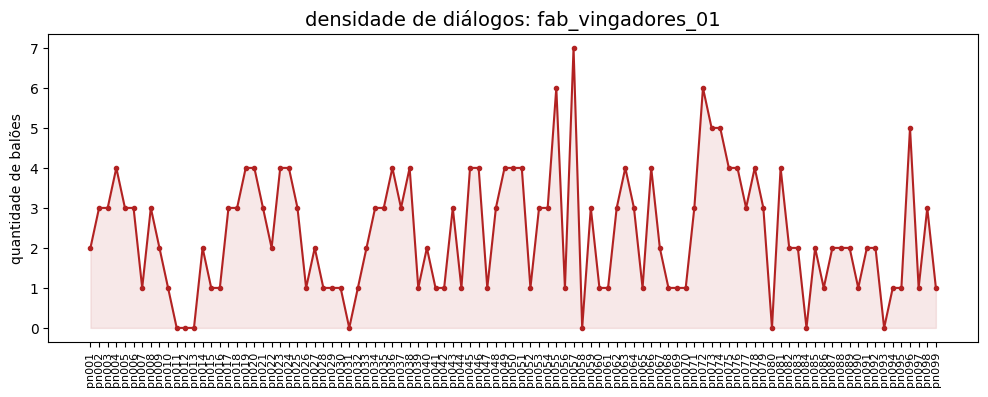

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import networkx as nx
import itertools

conn = sqlite3.connect('../marvel.db')
target_id = 'fab_vingadores_01' # o seu "id mestre" para o template

# carregar dados da edição
df_hq = pd.read_sql(f"select * from paineis_marvel where id_edicao = '{target_id}'", conn)

# função para extrair o total de balões de uma célula de 'vozes'
def contar_baloes(texto):
    if not texto or 'mudo' in texto and '(' not in texto: return 0
    # busca todos os (n) e soma, se não achar (n) mas tiver nome, assume 1
    numeros = re.findall(r'\((\d+)\)', texto)
    if numeros:
        return sum(int(n) for n in numeros)
    return len(texto.split(',')) if texto != 'mudo' else 0

df_hq['total_baloes'] = df_hq['vozes'].apply(contar_baloes)

plt.figure(figsize=(12, 4))
plt.plot(df_hq['id_painel'], df_hq['total_baloes'], color='firebrick', marker='.', linestyle='-')
plt.fill_between(df_hq['id_painel'], df_hq['total_baloes'], color='firebrick', alpha=0.1)
plt.title(f'densidade de diálogos: {target_id}', fontsize=14)
plt.ylabel('quantidade de balões')
plt.xticks(rotation=90, fontsize=8)
plt.show()

## matriz de presença (heatmap)

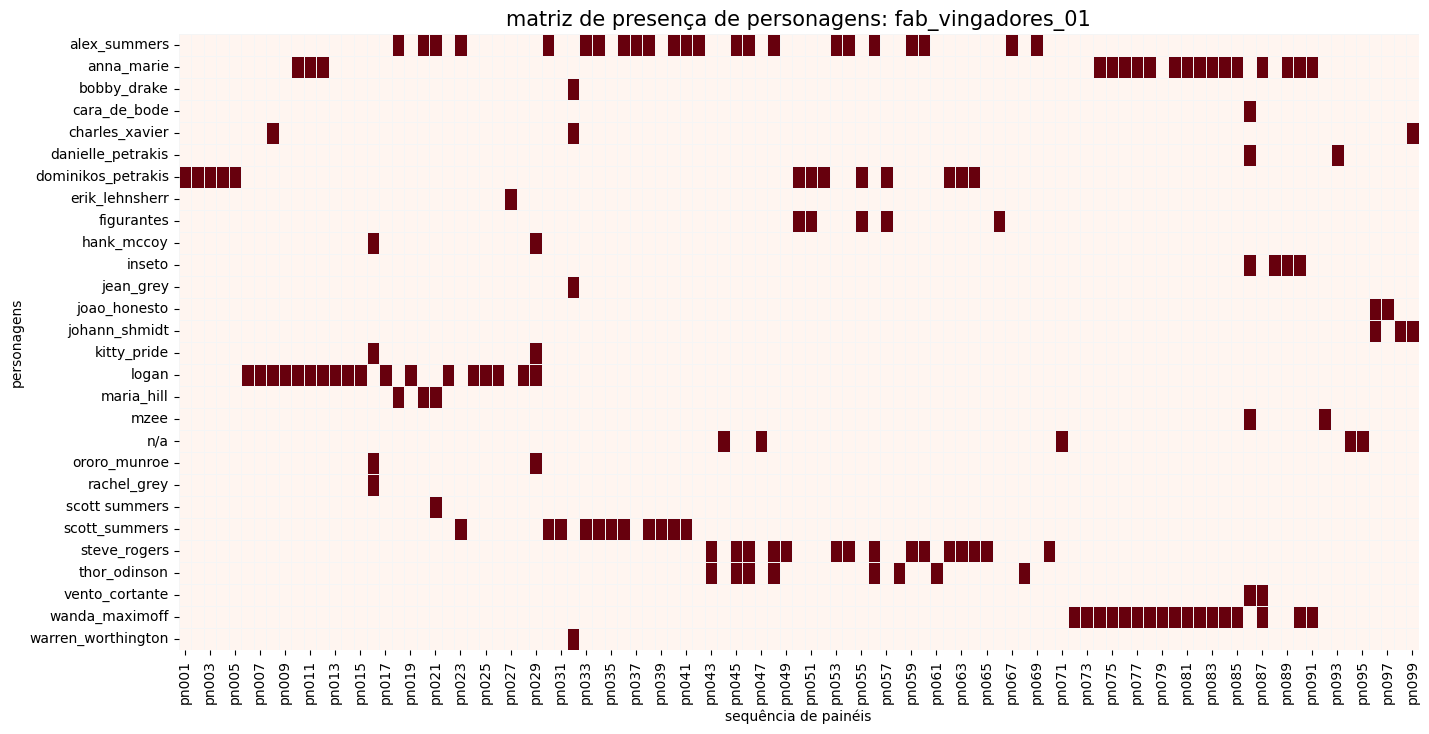

In [2]:
# 1. criar uma lista de todos os personagens únicos na edição
todos_personagens = set()
for linha in df_hq['personagens']:
    todos_personagens.update([p.strip() for p in linha.split(',')])

# 2. criar um dataframe de presença (0 ou 1)
presenca_data = []
for p in sorted(list(todos_personagens)):
    # verifica se o nome do personagem está na string de cada painel
    row = [1 if p in lista else 0 for lista in df_hq['personagens']]
    presenca_data.append(row)

df_heatmap = pd.DataFrame(presenca_data, index=sorted(list(todos_personagens)), columns=df_hq['id_painel'])

# 3. desenhar o heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(df_heatmap, cmap="Reds", cbar=False, linewidths=0.5, linecolor='whitesmoke')
plt.title(f'matriz de presença de personagens: {target_id}', fontsize=15)
plt.xlabel('sequência de painéis')
plt.ylabel('personagens')
plt.show()

## quem manda na voz (share of voice)

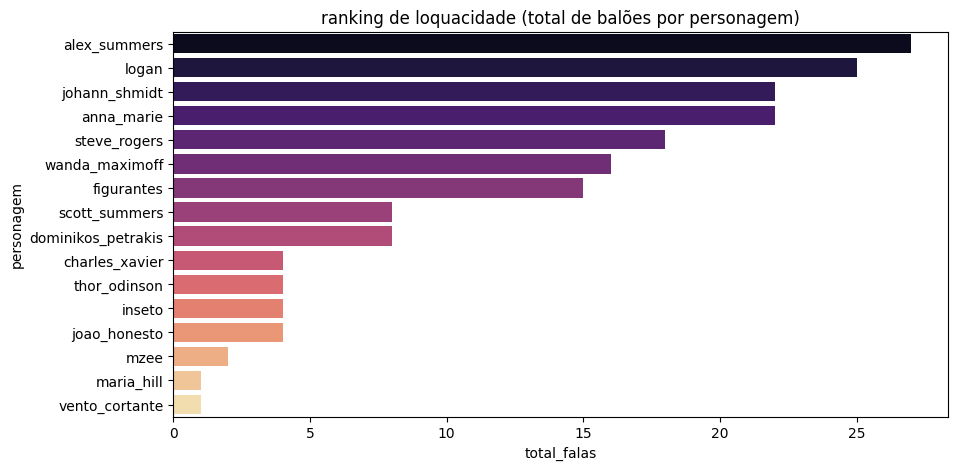

In [3]:
from collections import Counter

falas_personagem = Counter()

for linha in df_hq['vozes']:
    if linha == 'mudo': continue
    partes = linha.split(', ')
    for p in partes:
        if 'f_' in p:
            nome = p.split('(')[0].replace('f_', '')
            # extrai o número entre parênteses ou assume 1
            qtd = re.search(r'\((\d+)\)', p)
            num = int(qtd.group(1)) if qtd else 1
            falas_personagem[nome] += num

df_falas = pd.DataFrame(falas_personagem.items(), columns=['personagem', 'total_falas']).sort_values('total_falas', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_falas, x='total_falas', y='personagem', hue='personagem', palette='magma', legend=False)
plt.title('ranking de loquacidade (total de balões por personagem)')
plt.show()

## gramática visual (estilo do enquadramento)

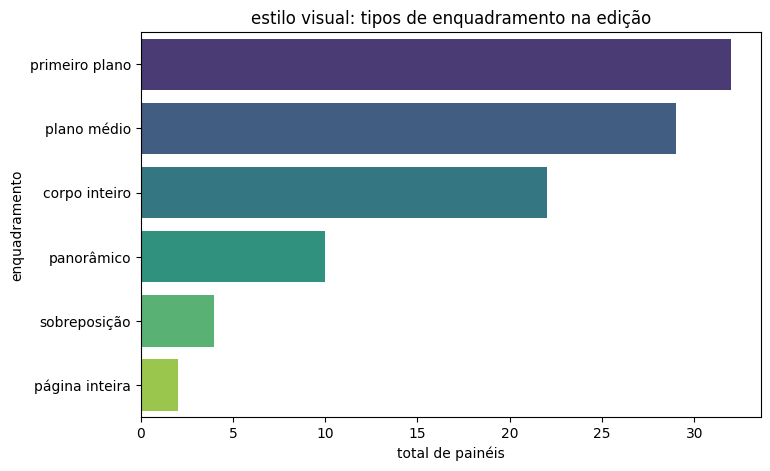

In [5]:
df_frames = df_hq['enquadramento'].value_counts().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_frames, x='count', y='enquadramento', hue='enquadramento', palette='viridis', legend=False)
plt.title('estilo visual: tipos de enquadramento na edição')
plt.xlabel('total de painéis')
plt.show()

## análise de silêncio (o "efeito mudo")

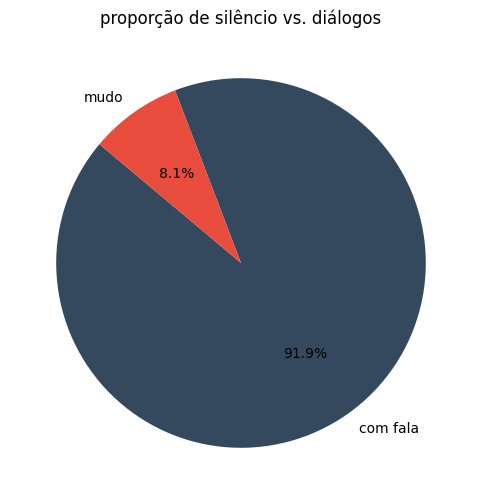

In [6]:
# define se o painel é mudo ou tem fala
df_hq['tipo_painel'] = df_hq['vozes'].apply(lambda x: 'mudo' if 'mudo' in x and '(' not in x else 'com fala')
dist_silencio = df_hq['tipo_painel'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(dist_silencio, labels=dist_silencio.index, autopct='%1.1f%%', colors=['#34495e', '#e74c3c'], startangle=140)
plt.title('proporção de silêncio vs. diálogos')
plt.show()

## resumo executivo da edição

In [7]:
# 1. cálculos rápidos para o resumo
total_paineis = len(df_hq)
personagem_mais_ativo = df_falas.iloc[0]['personagem'] if not df_falas.empty else "n/a"
total_falas_edicao = df_falas['total_falas'].sum() if not df_falas.empty else 0
media_baloes = df_hq['total_baloes'].mean()
enquadramento_dominante = df_hq['enquadramento'].mode()[0]
paineis_mudos = len(df_hq[df_hq['tipo_painel'] == 'mudo'])

# 2. criação de uma tabela de destaque (styled dataframe)
print(f"{'='*50}")
print(f"RESUMO ESTATÍSTICO: {target_id.upper()}")
print(f"{'='*50}")

resumo_df = pd.DataFrame({
    "métrica": ["total de painéis", "protagonista vocal", "volume de diálogos", "ritmo médio", "estilo visual", "momentos de silêncio"],
    "valor": [
        f"{total_paineis} quadros",
        f"{personagem_mais_ativo}",
        f"{total_falas_edicao} balões",
        f"{media_baloes:.1f} balões/painel",
        f"{enquadramento_dominante}",
        f"{paineis_mudos} painéis"
    ]
})

display(resumo_df)

# 3. parágrafo de análise automática (data storytelling)
print(f"\n--- análise narrativa ---")
print(f"a edição {target_id} apresenta um ritmo de leitura {('frenético' if media_baloes < 1.5 else 'denso')}, ")
print(f"com foco principal em {enquadramento_dominante}. o personagem '{personagem_mais_ativo}' domina a narrativa ")
print(f"com {total_falas_edicao} balões de fala, enquanto a ação pura (sem falas) ocupa {paineis_mudos} painéis da história.")

RESUMO ESTATÍSTICO: FAB_VINGADORES_01


,métrica,valor
0,total de painéis,99 quadros
1,protagonista vocal,alex_summers
2,volume de diálogos,181 balões
3,ritmo médio,2.4 balões/painel
4,estilo visual,primeiro plano
5,momentos de silêncio,8 painéis



--- análise narrativa ---
a edição fab_vingadores_01 apresenta um ritmo de leitura denso, 
com foco principal em primeiro plano. o personagem 'alex_summers' domina a narrativa 
com 181 balões de fala, enquanto a ação pura (sem falas) ocupa 8 painéis da história.
